In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, silhouette_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings


[1] Gerando dataset sintético...
Dataset criado: 2000 amostras, 20 features
Distribuição de classes: [1003  997]

[2] Preparando dados...

[3] Aplicando K-Means Clustering...
K-Means aplicado com 3 clusters

[4] Construindo Rede Neural com TensorFlow...

Arquitetura da Rede Neural:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)


[5] Treinando o modelo...

[6] Avaliando modelo...

Acurácia no teste: 0.9150
AUC no teste: 0.9382

[7] Gerando visualizações...


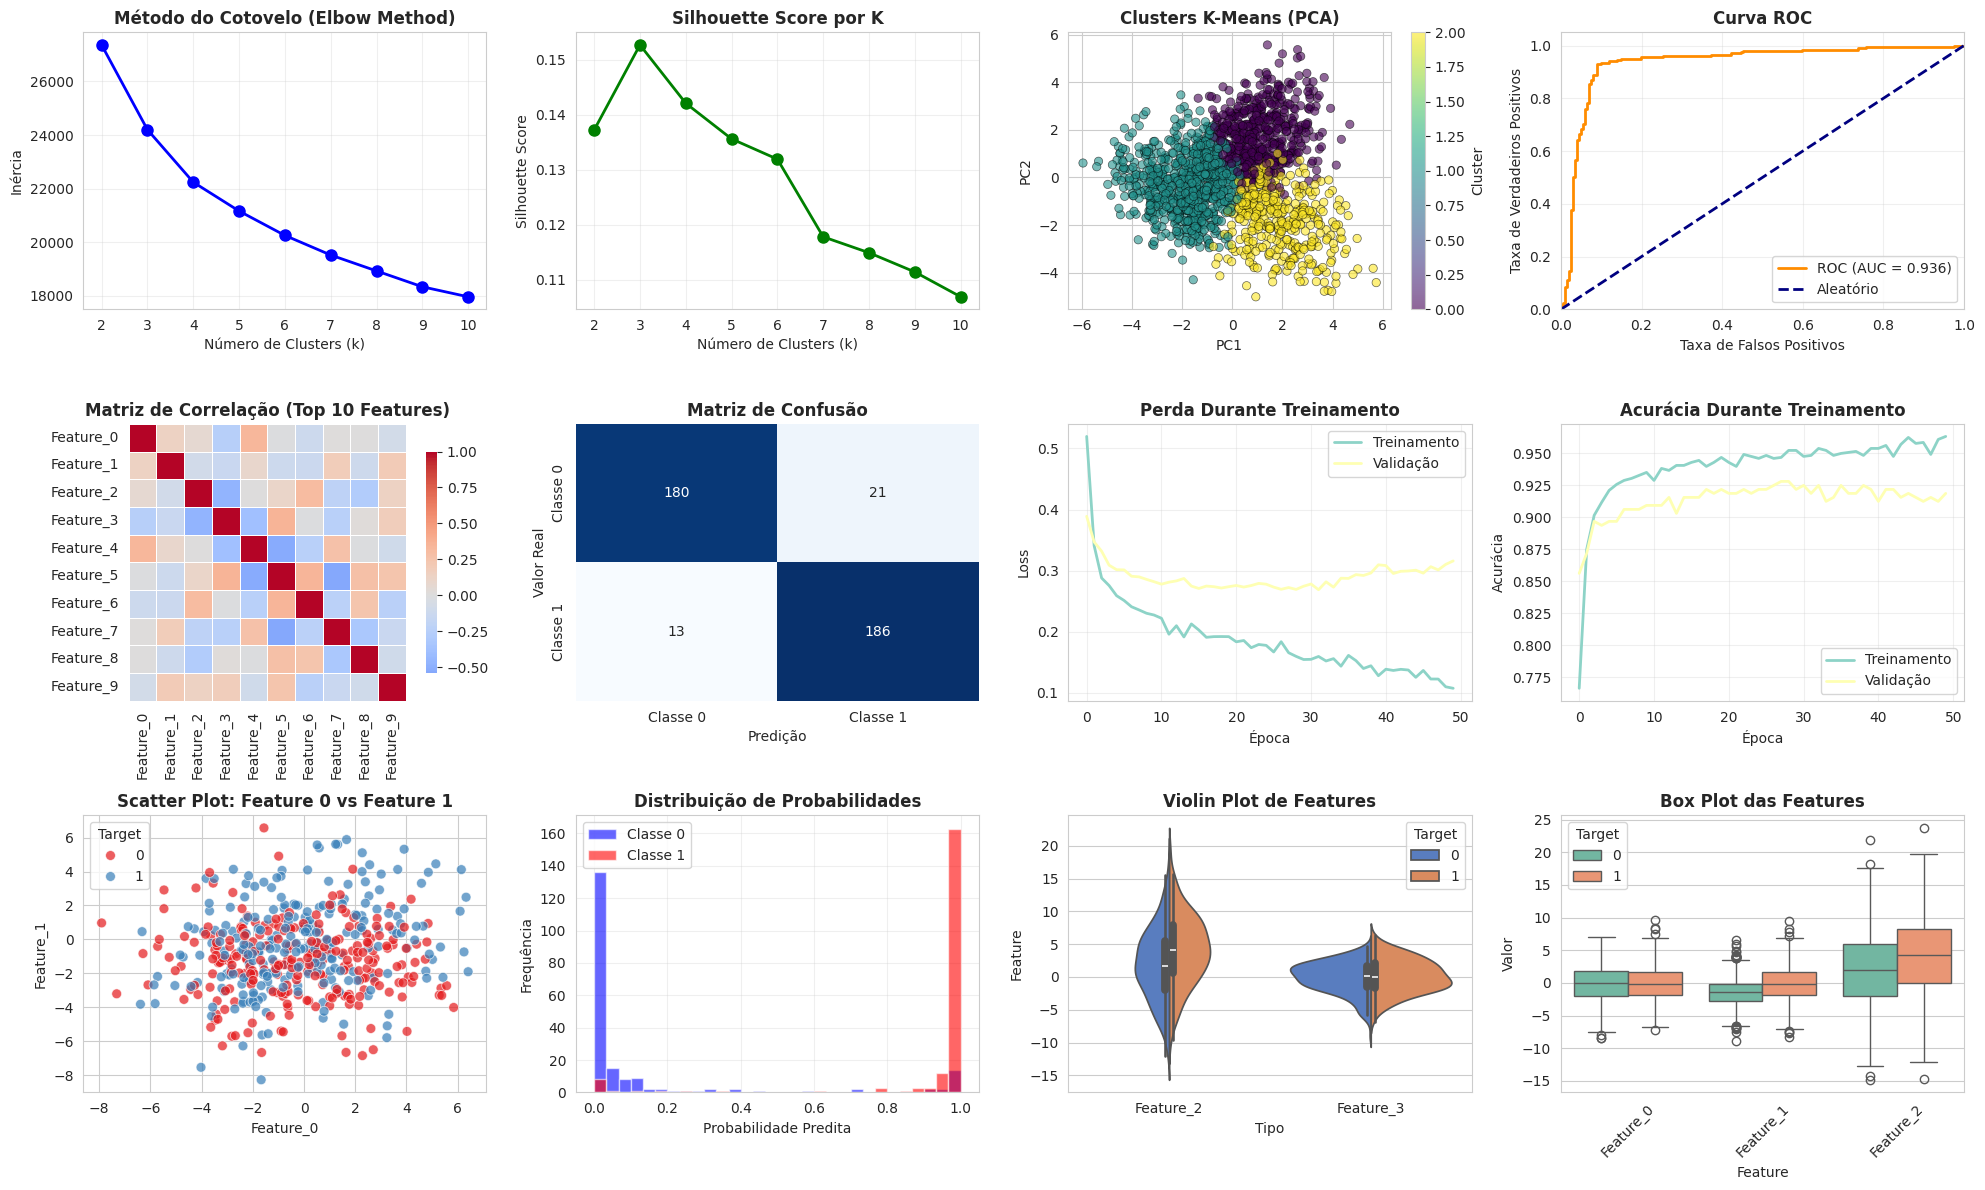


RELATÓRIO FINAL

📊 K-Means Clustering:
   - Clusters utilizados: 3
   - Silhouette Score: 0.1527

🧠 Deep Learning (Rede Neural):
   - Arquitetura: 20 → 128 → 64 → 32 → 1
   - Acurácia Final: 0.9150
   - AUC-ROC: 0.9356

📈 Curva ROC:
   - AUC Score: 0.9356
   - Interpretação: Excelente

📋 Classification Report:
              precision    recall  f1-score   support

    Classe 0       0.93      0.90      0.91       201
    Classe 1       0.90      0.93      0.92       199

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.91       400
weighted avg       0.92      0.92      0.91       400


✅ Análise completa finalizada!
   Gráfico salvo como 'ml_complete_analysis.png'


In [8]:
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)


print("\n[1] Gerando dataset sintético...")
X, y = make_classification(n_samples=2000, n_features=20, n_informative=15,
                          n_redundant=5, n_classes=2, random_state=42,
                          class_sep=1.5, flip_y=0.1)

feature_names = [f'Feature_{i}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

print(f"Dataset criado: {df.shape[0]} amostras, {df.shape[1]-1} features")
print(f"Distribuição de classes: {np.bincount(y)}")

# 2. PRÉ-PROCESSAMENTO
print("\n[2] Preparando dados...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. KMEANS CLUSTERING
print("\n[3] Aplicando K-Means Clustering...")
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

# Melhor número de clusters
best_k = 3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_train_scaled)
print(f"K-Means aplicado com {best_k} clusters")

# 4. DEEP LEARNING COM TENSORFLOW
print("\n[4] Construindo Rede Neural com TensorFlow...")

# Arquitetura da rede neural
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(20,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("\nArquitetura da Rede Neural:")
model.summary()

# Treinamento
print("\n[5] Treinando o modelo...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# 5. AVALIAÇÃO E PREDIÇÕES
print("\n[6] Avaliando modelo...")
y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Métricas
test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nAcurácia no teste: {test_acc:.4f}")
print(f"AUC no teste: {test_auc:.4f}")

# 6. CURVA ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 7. VISUALIZAÇÕES
print("\n[7] Gerando visualizações...")

fig = plt.figure(figsize=(20, 12))

# Subplot 1: Elbow Method para K-Means
ax1 = plt.subplot(3, 4, 1)
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=10)
plt.ylabel('Inércia', fontsize=10)
plt.title('Método do Cotovelo (Elbow Method)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 2: Silhouette Score
ax2 = plt.subplot(3, 4, 2)
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=10)
plt.ylabel('Silhouette Score', fontsize=10)
plt.title('Silhouette Score por K', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 3: Distribuição dos Clusters
ax3 = plt.subplot(3, 4, 3)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)
plt.title('Clusters K-Means (PCA)', fontsize=12, fontweight='bold')

# Subplot 4: Curva ROC
ax4 = plt.subplot(3, 4, 4)
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=10)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=10)
plt.title('Curva ROC', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 5: Matriz de Correlação (Heatmap Seaborn)
ax5 = plt.subplot(3, 4, 5)
corr_matrix = df[feature_names[:10]].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação (Top 10 Features)', fontsize=12, fontweight='bold')

# Subplot 6: Confusion Matrix
ax6 = plt.subplot(3, 4, 6)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Classe 0', 'Classe 1'],
            yticklabels=['Classe 0', 'Classe 1'])
plt.ylabel('Valor Real', fontsize=10)
plt.xlabel('Predição', fontsize=10)
plt.title('Matriz de Confusão', fontsize=12, fontweight='bold')

# Subplot 7: História do Treinamento - Loss
ax7 = plt.subplot(3, 4, 7)
plt.plot(history.history['loss'], label='Treinamento', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação', linewidth=2)
plt.xlabel('Época', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.title('Perda Durante Treinamento', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 8: História do Treinamento - Accuracy
ax8 = plt.subplot(3, 4, 8)
plt.plot(history.history['accuracy'], label='Treinamento', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validação', linewidth=2)
plt.xlabel('Época', fontsize=10)
plt.ylabel('Acurácia', fontsize=10)
plt.title('Acurácia Durante Treinamento', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 9: Scatter Plot com Seaborn
ax9 = plt.subplot(3, 4, 9)
sample_df = df.sample(500)
sns.scatterplot(data=sample_df, x='Feature_0', y='Feature_1',
                hue='Target', palette='Set1', s=50, alpha=0.7)
plt.title('Scatter Plot: Feature 0 vs Feature 1', fontsize=12, fontweight='bold')

# Subplot 10: Distribuição de Probabilidades
ax10 = plt.subplot(3, 4, 10)
plt.hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, label='Classe 0', color='blue')
plt.hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, label='Classe 1', color='red')
plt.xlabel('Probabilidade Predita', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.title('Distribuição de Probabilidades', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 11: Violin Plot com Seaborn
ax11 = plt.subplot(3, 4, 11)
plot_df = pd.DataFrame({
    'Feature': np.concatenate([sample_df['Feature_2'], sample_df['Feature_3']]),
    'Tipo': ['Feature_2']*len(sample_df) + ['Feature_3']*len(sample_df),
    'Target': np.concatenate([sample_df['Target'], sample_df['Target']])
})
sns.violinplot(data=plot_df, x='Tipo', y='Feature', hue='Target',
               split=True, palette='muted')
plt.title('Violin Plot de Features', fontsize=12, fontweight='bold')

# Subplot 12: Box Plot com Seaborn
ax12 = plt.subplot(3, 4, 12)
box_data = df[['Feature_0', 'Feature_1', 'Feature_2', 'Target']].melt(
    id_vars='Target', var_name='Feature', value_name='Valor'
)
sns.boxplot(data=box_data, x='Feature', y='Valor', hue='Target', palette='Set2')
plt.title('Box Plot das Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('ml_complete_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. RELATÓRIO FINAL
print("\n" + "="*60)
print("RELATÓRIO FINAL")
print("="*60)
print(f"\n📊 K-Means Clustering:")
print(f"   - Clusters utilizados: {best_k}")
print(f"   - Silhouette Score: {silhouette_scores[best_k-2]:.4f}")

print(f"\n🧠 Deep Learning (Rede Neural):")
print(f"   - Arquitetura: 20 → 128 → 64 → 32 → 1")
print(f"   - Acurácia Final: {test_acc:.4f}")
print(f"   - AUC-ROC: {roc_auc:.4f}")

print(f"\n📈 Curva ROC:")
print(f"   - AUC Score: {roc_auc:.4f}")
print(f"   - Interpretação: {'Excelente' if roc_auc > 0.9 else 'Bom' if roc_auc > 0.8 else 'Razoável'}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Classe 0', 'Classe 1']))

print("\n✅ Análise completa finalizada!")
print("   Gráfico salvo como 'ml_complete_analysis.png'")
print("="*60)